In [4]:
import os
import math
import wandb
import random
import time
import logging
import inspect
import argparse
import datetime
import numpy as np

from pathlib import Path
from tqdm.auto import tqdm
from einops import rearrange, repeat
from omegaconf import OmegaConf
from typing import Dict, Optional, Tuple

import torch
import torch.nn.functional as F
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader

import diffusers
from diffusers import AutoencoderKL, DDIMScheduler
from diffusers.optimization import get_scheduler
from diffusers.utils import check_min_version
from diffusers.utils.import_utils import is_xformers_available
from diffusers.training_utils import EMAModel

import transformers
from transformers import CLIPTextModel, CLIPTokenizer

from accelerate import Accelerator, DistributedDataParallelKwargs, InitProcessGroupKwargs
from accelerate.logging import get_logger
from accelerate.utils import set_seed

from swomo.data.dataset import SurgicalDataset
from swomo.models.videoldm_unet import VideoLDMUNet3DConditionModel
from swomo.models.videoldm_controlnet import ControlNetModel
from swomo.graph_encoder.graph_segclip_masked import GraphEncoder
from swomo.pipelines.pipeline_conditional_animation import ConditionalAnimationPipeline
from swomo.pipelines.pipeline_controlnet_animation import ControlNetAnimationPipeline
from swomo.utils.util import save_videos_grid, save_videos_grid_from_paths
from swomo.utils.get_scene_graph import GraphConstructor




import matplotlib.pyplot as plt
from PIL import Image
import json

/home/MichalMo/anaconda3/envs/swomo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/MichalMo/anaconda3/envs/swomo/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.0'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [158]:
import cv2
from matplotlib import animation
from IPython.display import HTML



def video_to_numpy(path, target_fps=None):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        raise RuntimeError("Cannot open video")

    original_fps = cap.get(cv2.CAP_PROP_FPS)
    step = 1 if not target_fps else max(1, int(round(original_fps / target_fps)))

    frames = []
    i = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if i % step == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        i += 1

    cap.release()
    return np.array(frames)

In [159]:
def load_SurgicalDataset_fromlist(loaded_list, eval_video_path):

    print(loaded_list)
    
    print(eval_video_path)

    image = np.array(Image.open(image).convert("RGB"))
    frames = np.array(frames)
    pixel_values = torch.from_numpy(frames).permute(0, 3, 1, 2).contiguous()
    pixel_values = pixel_values / 255.0

In [168]:
def search(test_dataset, loaded_list_frames):

    for i in range(len(test_dataset.sample)):
        frames = test_dataset.__getitem__(i)["all_frame_path"]

        frames2 = [x.split("/")[-1] for x in frames]


        # if i > 2:
        #     break

        if frames2 == loaded_list_frames:

            print(frames[0], frames[-1])

            return i

In [169]:
path = "<OUTPUT_DIR>/00008"

directory = Path(path)
    
eval_video_path = list(directory.glob("*.mp4"))[0]
json_path = list(directory.glob("*.json"))[0]

# eval_video_path = "<OUTPUT_DIR>/00000/0000000000-0000000015.mp4"
# json_path = "<OUTPUT_DIR>/00000/case_2010.json"

print(eval_video_path)
print(json_path)

with open(json_path, 'r') as f:
    loaded_list = json.load(f)

loaded_list_frames = [x.split("/")[-1] for x in loaded_list]
loaded_list_frames


# eval_images = load_SurgicalDataset_fromlist(loaded_list, eval_video_path)



eval_images = video_to_numpy(eval_video_path, target_fps=1)
print(eval_images.dtype)
print(np.max(eval_images))


#######################



config = OmegaConf.load("configs/inference/inference_img_graph_vid_cataracts.yaml")

test_dataset = SurgicalDataset(**config.test_data)


ind = search(test_dataset, loaded_list_frames)

org_images = test_dataset.__getitem__(ind)["pixel_values"].permute(0, 2,3,1)
org_images.shape

img_unnorm = (org_images * 0.5) + 0.5
img_unnorm = (torch.clamp(img_unnorm, 0.0, 1.0)*255).to(torch.uint8)

<OUTPUT_DIR>/00008/0000000064-0000000079.mp4
<OUTPUT_DIR>/00008/case_2010.json
uint8
255
datasets/Cataract-1K/video_frames_jpg/case_2010/0000000064.jpg datasets/Cataract-1K/video_frames_jpg/case_2010/0000000079.jpg


uint8 255


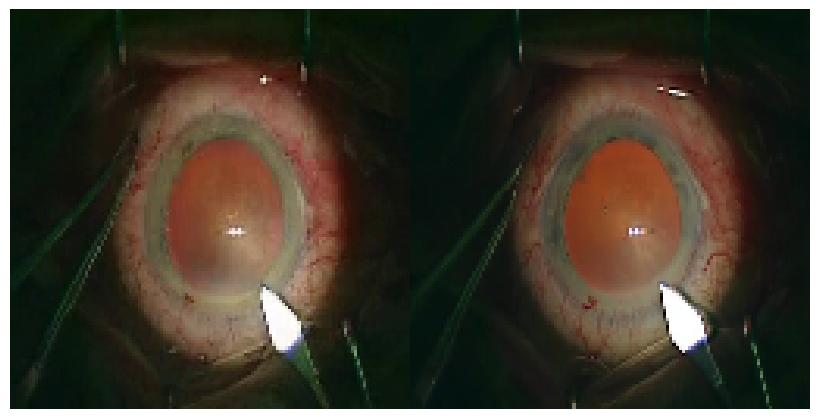

In [170]:
# eval_images = (eval_images.astype(np.float32))
# eval_images = (eval_images/255.0)#.astype(np.float32)

print(eval_images.dtype, np.max(eval_images))
video_vis = np.concatenate([eval_images, img_unnorm], axis = 2)


fig = plt.figure(figsize=(8, 4))
ax = plt.gca()
ax.axis("off")
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)


if video_vis.ndim == 3:  # grayscale
    im = ax.imshow(video_vis[0], cmap="gray", animated=True)
else:               # RGB
    im = ax.imshow(video_vis[0], animated=True)

def update(i):
    im.set_array(video_vis[i])
    return [im]



anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(video_vis),
    interval=1000,  # ms per frame (10 FPS)
    blit=True
)

HTML(anim.to_jshtml())